<a href="https://colab.research.google.com/github/ifeomagold16ph/eye-health-data-analysis/blob/main/Global_Trends_in_Vision_Impairment_A_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Trends in Vision Impairment
**Author:** Ifeoma Ofili

**Date:** 21 March 2026

**Objective:** Analyze global vision impairment and blindness data to identify trends, high-risk populations, and regional disparities.

**Tools:** Python, Pandas, NumPy, Matplotlib

**Dataset:** Global vision impairment CSV

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Why these libraries?
- **Pandas:** For data cleaning, manipulation, and summarizing large datasets  
- **NumPy:** For numerical calculations and data transformations  
- **Matplotlib:** To create visualizations of trends across regions and age groups


In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv('vision_dataset.csv')

# Data Loading
The dataset was uploaded manually into the notebook environment and loaded using Pandas for analysis.

In [ ]:
!pip install datasets

from datasets import load_dataset
import pandas as pd

ds = load_dataset("electricsheepafrica/visual-impairment-low-vision", "urban_eye_clinic")
df = pd.DataFrame(ds["train"])

df.head()
df.columns

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

vision_urban.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Index(['record_id', 'scenario', 'year', 'setting', 'age', 'sex', 'cause',
       'severity', 'bilateral', 'avoidable', 'screened', 'referred',
       'referral_completed', 'ophthalmologist_seen', 'spectacles_needed',
       'spectacles_received', 'cataract_surgery_needed',
       'cataract_surgery_done', 'surgery_outcome_good', 'low_vision_device',
       'cost_barrier', 'distance_barrier', 'awareness_barrier',
       'vision_improved', 'employment_impacted', 'quality_of_life_improved',
       'unmet_need'],
      dtype='object')

# Initial Data Exploration
To understand the structure of the dataset, we begin by examining the number of observations and summary statistics,
This helps identify missing values, data distribution, and overall dataset quality before performing further analysis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   record_id                 10000 non-null  object
 1   scenario                  10000 non-null  object
 2   year                      10000 non-null  int64 
 3   setting                   10000 non-null  object
 4   age                       10000 non-null  int64 
 5   sex                       10000 non-null  object
 6   cause                     10000 non-null  object
 7   severity                  10000 non-null  object
 8   bilateral                 10000 non-null  int64 
 9   avoidable                 10000 non-null  int64 
 10  screened                  10000 non-null  int64 
 11  referred                  10000 non-null  int64 
 12  referral_completed        10000 non-null  int64 
 13  ophthalmologist_seen      10000 non-null  int64 
 14  spectacles_needed      

# Summary Statistics
We generate descriptive statistics to understand the distribution of numerical variables such as age.
This includes measures like mean, minimum, maximum, and standard deviation, which provide insights into the population being studied.

In [ ]:
df.describe()

,year,age,bilateral,avoidable,screened,referred,referral_completed,ophthalmologist_seen,spectacles_needed,spectacles_received,...,cataract_surgery_done,surgery_outcome_good,low_vision_device,cost_barrier,distance_barrier,awareness_barrier,vision_improved,employment_impacted,quality_of_life_improved,unmet_need
count,10000.0000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2017.6198,44.548500,0.599600,0.70720,0.552800,0.275500,0.093100,0.056100,0.476800,0.16750,...,0.054500,0.044500,0.019300,0.501100,0.400100,0.447000,0.154200,0.289000,0.106300,0.377800
std,4.3005,19.853596,0.490004,0.45507,0.497229,0.446788,0.290587,0.230126,0.499486,0.37344,...,0.227013,0.206213,0.137584,0.500024,0.489943,0.497208,0.361158,0.453321,0.308237,0.484861
min,2010.0000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2014.0000,31.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2018.0000,44.000000,1.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2021.0000,58.000000,1.000000,1.00000,1.000000,1.000000,0.000000,0.000000,1.000000,0.00000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,2024.0000,90.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Distribution of Participants by Sex
We examine the number of male and female participants in the dataset. This helps assess whether the sample is balanced and whether gender may influence the outcomes of interest.

In [ ]:
df['sex'].value_counts()

,count
sex,
female,5556
male,4444


# Causes of Visual Impairment
We analyze the frequency of different causes of visual impairment.
This allows us to identify the most common conditions affecting patients in the dataset.

In [ ]:
df['cause'].value_counts()

,count
cause,
cataract,3546
refractive_error,2506
glaucoma,1153
diabetic_retinopathy,790
other,515
corneal_opacity,512
trachoma,508
childhood_blindness,470


# Summary of Clinical Needs
We calculate the total number of patients requiring specific interventions, including:
- Referral
- Spectacles
- Cataract surgery
- Low vision devices

This provides an overview of the healthcare needs within the population.

In [ ]:
df[['referred', 'spectacles_needed', 'cataract_surgery_needed', 'low_vision_device']].sum()

,0
referred,2755
spectacles_needed,4768
cataract_surgery_needed,1406
low_vision_device,193


In [ ]:
# The dataset comprises 10,000 patients, of which 55.6% are female and 44.4% are male
df['sex'].value_counts(normalize=True) * 100

,proportion
sex,
female,55.56
male,44.44


In this cohort of 10,000 patients, females were slightly more represented (55.6%). Cataract and refractive errors were the leading causes of eye conditions. Nearly half of the patients required corrective spectacles, while a smaller proportion needed cataract surgery or referral for specialized care.

The dataset comprises 10,000 patients, of which 55.6% are female and 44.4% are male. Cataract was the most common cause of eye conditions (35.5%), followed by refractive error (25.1%) and glaucoma (11.5%). Less frequent causes included diabetic retinopathy (7.9%), corneal opacity (5.1%), trachoma (5.1%), childhood blindness (4.7%), and other conditions (5.2%).

Among patients, 27.6% were referred for further care, 47.7% required spectacles, and 14.1% needed cataract surgery, and 1.9% of patients required a low vision device.

# Low Vision Device Requirement
We examine how many patients require low vision devices.
This helps quantify the burden of visual impairment that cannot be corrected with standard treatments.

In [ ]:
df['low_vision_device'].value_counts()

,count
low_vision_device,
0,9807
1,193


# Binary Outcomes Analysis
We analyze binary clinical outcomes (Yes/No) such as referral, need for spectacles, cataract surgery, and low vision devices.
Bar charts are used to visualize the number of patients in each category, making it easier to compare healthcare needs.

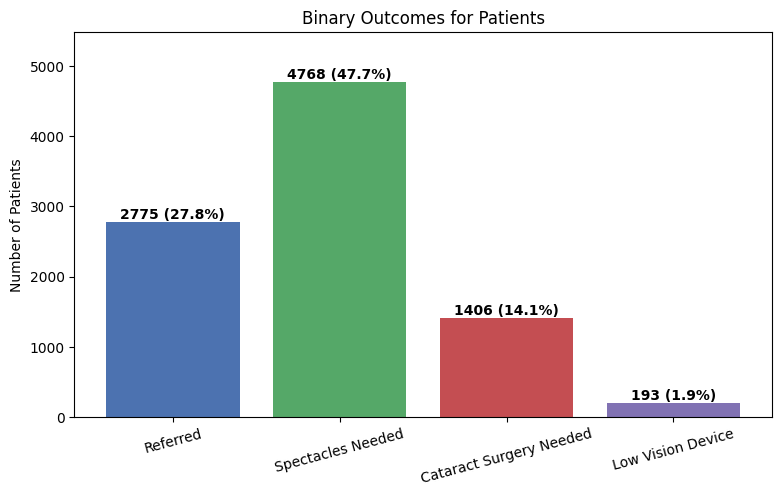

In [ ]:
import matplotlib.pyplot as plt

# Binary outcomes and their counts
outcomes = ['Referred', 'Spectacles Needed', 'Cataract Surgery Needed', 'Low Vision Device']
counts = [2775, 4768, 1406, 193] # actual counts

# Optional: percentages for reference
total_patients = 10000
percentages = [count/ total_patients * 100 for count in counts]

# Create the bar chart
plt.figure(figsize=(9,5))
bars = plt.bar(outcomes, counts, color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'])
# Add value labels on top of each bar
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f"{counts[i]} ({percentages[i]:.1f}%)",
             ha='center', fontweight='bold')

plt.ylabel('Number of Patients')
plt.title('Binary Outcomes for Patients')
plt.xticks(rotation=15)
plt.ylim(0, max(counts)*1.15) # add some space for labels above bars
plt.show()

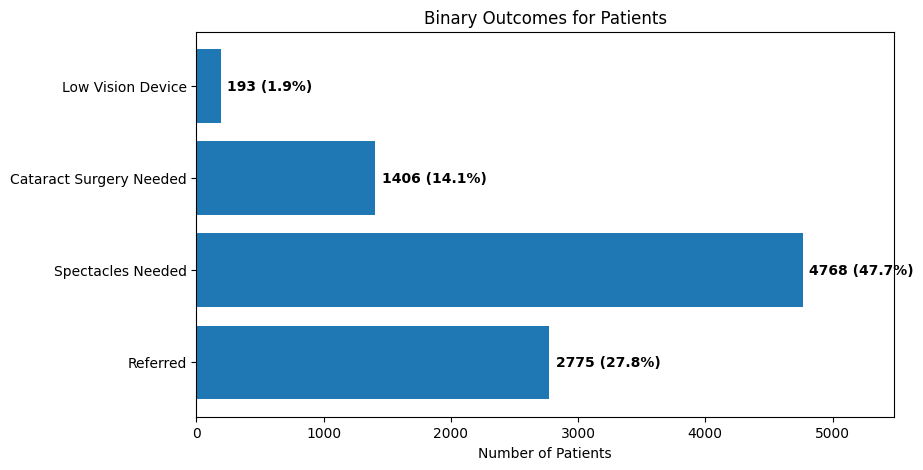

In [ ]:
import matplotlib.pyplot as plt

# Data
outcomes = ['Referred', 'Spectacles Needed', 'Cataract Surgery Needed', 'Low Vision Device']
counts = [2775, 4768, 1406, 193]

# Percentages
total_patients = 10000
percentages = [count/ total_patients * 100 for count in counts]

# Create horizontal bar chart
plt.figure(figsize=(9,5))
bars = plt.barh(outcomes, counts)

# Add labels (counts + percentage)
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 50, bar.get_y() + bar.get_height()/2, f"{counts[i]} ({percentages[i]:.1f}%)",
             va='center', fontweight='bold')

plt.xlabel('Number of Patients')
plt.title('Binary Outcomes for Patients')
plt.xlim(0, max(counts)*1.15) # space for labels
plt.show()

The majority of patients required spectacles, while referrals and cataract surgeries were less common. Only a small proportion required low vision devices.

# Cross-tabulation Analysis
We perform cross-tabulation to explore relationships between the cause of visual impairment and clinical needs, including:

Cause vs Catract Surgery Needed
Cause vs Spectacles Needed
Cause vs Referral

This helps identify which conditions are most associated with specific interventions and supports targeted healthcare planning.

In [ ]:
import pandas as pd

pd.crosstab(df['cause'], df['cataract_surgery_needed'])

cataract_surgery_needed,0,1
cause,,
cataract,2140,1406
childhood_blindness,470,0
corneal_opacity,512,0
diabetic_retinopathy,790,0
glaucoma,1153,0
other,515,0
refractive_error,2506,0
trachoma,508,0


Cataract was the only condition associated with the need for cataract surgery, with 39.7% of cataract cases requiring surgical intervention, while no other causes required surgery.

Total cataract cases = 2140 + 1406 = 3546
1406/3546 x 100 = 39.7%(approx)

In [ ]:
pd.crosstab(df['cause'], df['spectacles_needed'], normalize='index') * 100

spectacles_needed,0,1
cause,,
cataract,70.050761,29.949239
childhood_blindness,70.212766,29.787234
corneal_opacity,70.117188,29.882812
diabetic_retinopathy,67.848101,32.151899
glaucoma,70.338248,29.661752
other,68.155340,31.844660
refractive_error,0.000000,100.000000
trachoma,71.062992,28.937008


All patients with refractive error (100%) required spectacles, indicating a perfect association between refractive error and the need for corrective lenses. Other causes such as diabetic retinopathy, cataract, glaucoma, corneal opacity and others showed lower proportions of patients equiring spectacles.

In [ ]:
pd.crosstab(df['cause'], df['referred'], normalize='index') * 100

referred,0,1
cause,,
cataract,72.870840,27.129160
childhood_blindness,71.702128,28.297872
corneal_opacity,72.656250,27.343750
diabetic_retinopathy,73.037975,26.962025
glaucoma,73.113617,26.886383
other,71.456311,28.543689
refractive_error,72.306464,27.693536
trachoma,69.291339,30.708661


Referral rates were relatively consistent across all causes of visual impairment, ranging from approximately 26% to 31%. Trachoma had the highest referral proportion (30.7%), while other conditions such as cataract, glaucoma, and refractive error showed similar referral patterns. This suggests that referral for further care is not strongly associated with any single cause.

Referral patterns were relatively uniform across all causes, suggesting that referral may be influenced by factors other than the underlying condition, such as severity or need for specialized care.

Cataract was the only condition associated with surgical intervention, with a substantial proportion of cataract cases requiring surgery. Refractive error showed a perfect association with spectacle use, as all affected patients required corrective lenses. In contrast, referral rates were relatively uniform across all causes, suggesting that the need for further care is not condition-specific but broadly distributed among patients.

In [ ]:
from datasets import load_dataset
import pandas as pd

# Load the dataset to ensure 'ds' is defined
ds = load_dataset("electricsheepafrica/visual-impairment-low-vision", "urban_eye_clinic")

# Convert Hugging Face dataset to pandas DataFrame
df = ds['train'].to_pandas()

# Save as CSV
df.to_csv('vision_dataset.csv', index=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

vision_urban.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
print(type(ds))
print(ds)

<class 'datasets.dataset_dict.DatasetDict'>
DatasetDict({
    train: Dataset({
        features: ['record_id', 'scenario', 'year', 'setting', 'age', 'sex', 'cause', 'severity', 'bilateral', 'avoidable', 'screened', 'referred', 'referral_completed', 'ophthalmologist_seen', 'spectacles_needed', 'spectacles_received', 'cataract_surgery_needed', 'cataract_surgery_done', 'surgery_outcome_good', 'low_vision_device', 'cost_barrier', 'distance_barrier', 'awareness_barrier', 'vision_improved', 'employment_impacted', 'quality_of_life_improved', 'unmet_need'],
        num_rows: 10000
    })
})
